In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.core as si

## Loading a channel from concatenated ADC

Loading SpikeInterface recording object (loads traces_cached_seg0.raw binary file + metadata in .json files)

In [140]:
DATA_PATH  = Path(r"R:\Basic_Sciences\Phys\SenzaiLab\Yiwen\mouse4\20260209")
ADC_PATH   = DATA_PATH / "OneBox-ADC"

rec = si.load(ADC_PATH / "concat")
rec

BinaryFolderRecording: 12 channels - 30300.500000 Hz - 1 segments - 275,173,881 samples 
                       9,081.50s (2.52 hours) - int16 dtype - 6.15 GiB

Select a channel by specifying channel ids

In [5]:
channel_ids = rec.get_channel_ids()
print(channel_ids)
cam_ch = rec.get_traces(channel_ids=[channel_ids[1]]).squeeze()
cam_ch.shape

['ADC0' 'ADC1' 'ADC2' 'ADC3' 'ADC4' 'ADC5' 'ADC6' 'ADC7' 'ADC8' 'ADC9'
 'ADC10' 'ADC11']


(275173881,)

Visualize the channel (should be 16-bit integer resolution voltage time series)

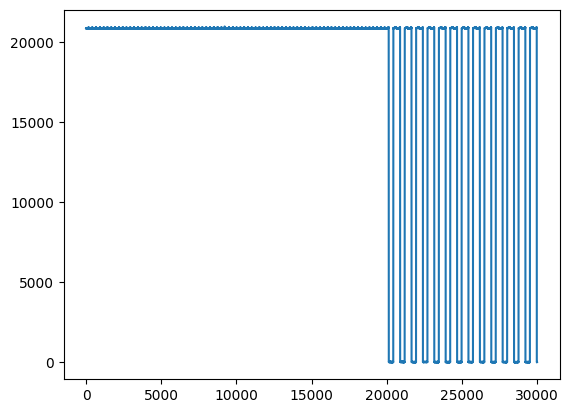

In [ ]:
t_start, t_end = 30000*16, 30000*17 # example time window
plt.plot(cam_ch[t_start:t_end])

## Extracting TTL pulse timestamps from the raw signal

In general digital sigals can have LOW (0V ~ 0.4V in int16 format) or HIGH (2.4V ~ 5V in int16 format) states.

Transitions are defined as rising edge (LOW to HIGH) or falling edge (HIGH to LOW).


In [ ]:
# Determine the threshold to separate HIGH and LOW states
threshold = (np.min(cam_ch) + np.max(cam_ch)) / 2
print(f"Threshold: {threshold:.4f}")

# Binarize the signal
binary_signal = (cam_ch > threshold).astype(np.int8)

# Detect edges
edges = np.where(np.diff(binary_signal))[0] + 1 # any transitions
rising_edges = np.where(np.diff(binary_signal) == 1)[0] + 1 # 0 -> 1
falling_edges = np.where(np.diff(binary_signal) == -1)[0] + 1 # 1 -> 0

print(f"Rising edges detected: {len(rising_edges)}")
print(f"Falling edges detected: {len(falling_edges)}")
print(f"Total edges: {len(edges)}")

Threshold: 10510.0000
Rising edges detected: 226457
Falling edges detected: 226458
Total edges: 452915


Visualize detected transitions

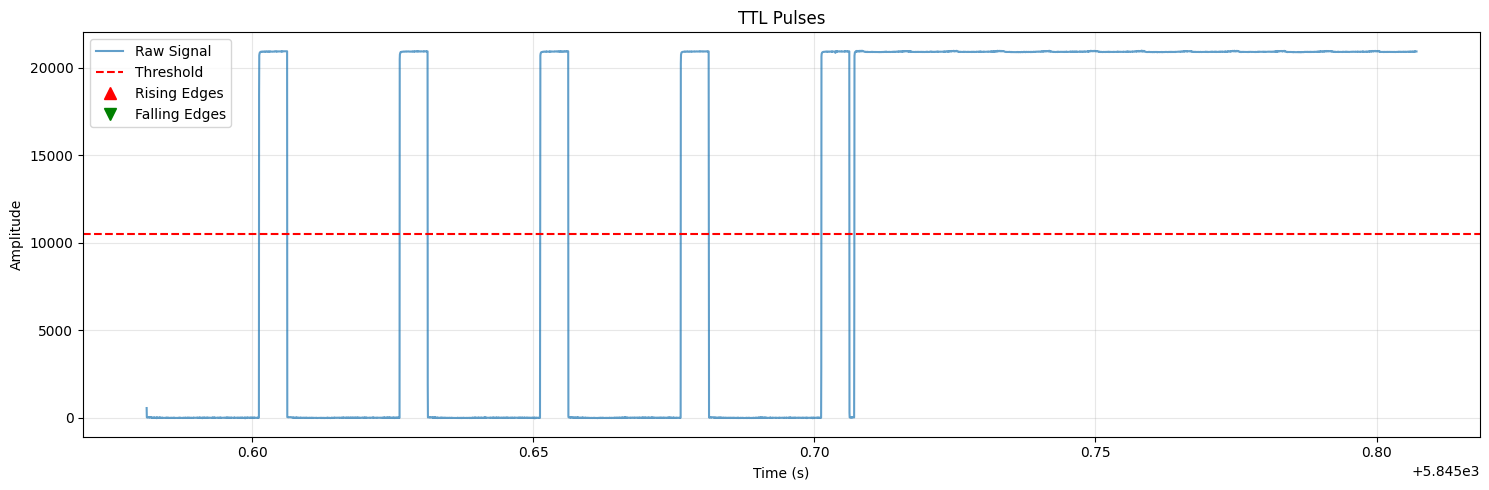

In [131]:
plt.figure(figsize=(15, 5))
time = rec.get_times()

# First 30 edges (15 pulses)
start_idx = -3
end_idx = 0
padding = int(0.1 * rec.get_sampling_frequency()) # 10 ms padding
s = slice(falling_edges[start_idx] - padding, rising_edges[end_idx - 1] + padding)

plt.plot(time[s], cam_ch[s], label='Raw Signal', alpha=0.7)
plt.axhline(y=threshold, color='red', linestyle='dashed', label='Threshold')

# Plot edges
mask_rising = rising_edges[start_idx:end_idx]
mask_falling = falling_edges[start_idx:end_idx]

plt.plot(time[mask_rising], cam_ch[mask_rising], 'r^', markersize=8, label='Rising Edges')
plt.plot(time[mask_falling], cam_ch[mask_falling], 'gv', markersize=8, label='Falling Edges')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('TTL Pulses')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

###

Select middle points between rising and falling edge as pulse timing.

In [114]:
dff = np.diff(rising_edges)
dff.min(), dff.max(), np.median(dff), np.mean(dff)

(np.int64(178),
 np.int64(5069050),
 np.float64(758.0),
 np.float64(779.9635072596884))

In [133]:
falling_edges

array([   500130,    500888,    501645, ..., 177127064, 177127822,
       177257709], shape=(226458,))

In [134]:
rising_edges

array([   500433,    501191,    501949, ..., 177126913, 177127671,
       177127849], shape=(226457,))

In [137]:
dff = np.diff(falling_edges)
thresh_low = np.median(dff * .8)
thresh_high = np.median(dff * 1.2)

idx = np.where((dff > thresh_low) | (dff < thresh_high))[0] + 1
falling = falling_edges[idx]
falling

array([   500888,    501645,    502403, ..., 177127064, 177127822,
       177257709], shape=(226457,))

In [136]:
dff = np.diff(rising_edges)
thresh_low = np.median(dff * .9)
thresh_high = np.median(dff * 1.1)

idx = np.where((dff > thresh_low) | (dff < thresh_high))[0] + 1
rising = rising_edges[idx]
rising

array([   501191,    501949,    502706, ..., 177126913, 177127671,
       177127849], shape=(226456,))

In [ ]:
if rising_edges[0] > falling_edges[0]:
    # First edge is rising edge, the baseline is at LOW state. 
    pass 
else:
    # First edge is falling edge, the baseline is at HIGH state.
    if len(rising_edges) == len(falling_edges):
        middle_points = (rising_edges + falling_edges) // 2
    else:
        #TODO
        # Filter out outliers    

### Interpolating sample numbers to timestamps

In [143]:
samples = np.load(ADC_PATH / 'global_samples.npy')
timestamps = np.load(ADC_PATH / 'global_timestamps.npy')

print(f"Samples shape: {samples.shape}")
print(f"Timestamps shape: {timestamps.shape}")

Samples shape: (24013,)
Timestamps shape: (24013,)


In [146]:
#TODO Replace rising_edges with filtered middle points
pulse_timestamps = np.interp(rising_edges, samples, timestamps)
pulse_timestamps

array([  17.51433704,   17.53935139,   17.56436574, ..., 5846.18334794,
       5846.20836192, 5846.21423591], shape=(226457,))